In [8]:
import pandas as pd
import numpy as np
import torch
from sklearn.preprocessing import StandardScaler

## Explanation

This file trains and runs LSTM models for 30, 50, and 70 cloudiness datasets using ONLY satellite data (not including weather). This serves as a baseline to understand the importance of weather data in predicting log of cyanobacteria abundance. Hyperparameter testing occurred beforehand to determine loss functions and learning rates.

#### 30% Cloudiness LSTM

In [58]:
df1 = pd.read_csv('cloud_30_7.csv')
print(df1.shape)
df1.shape[0] / 7 #number of unique samples

(33509, 20)


4787.0

In [59]:
#sort
df1 = df1.sort_values(by = ['latitude', 'longitude', 'sample_date', 'cyanobacteria_abundance', 'satellite_date'])

In [60]:
#placing data into the correct format to load into the LSTM
feature_cols = ['NIR', 'SWIR', 'blue', 'green', 'ndci', 'ndti', 'ndvi', 'ndwi', 'red', 'red_edge', 'cloud_score', 'mean_diff_days', 'std_diff_days']
xdata = []
ydata = []

groups = ['latitude', 'longitude', 'sample_date', 'cyanobacteria_abundance'] 

for _, group in df1.groupby(groups):
    group = group.sort_values('satellite_date')

    #ensure sequence is of length 7
    if len(group) == 7:
        seq = group[feature_cols].values

        #input features
        xdata.append(seq)

        #target feature
        ydata.append(group['cyanobacteria_abundance'].iloc[0])

xdata = np.array(xdata)
ydata = np.array(ydata)

#take log of cyanobacteria abundance
ydata = np.log1p(ydata)

print(xdata.shape)
print(ydata.shape)

(4787, 7, 13)
(4787,)


In [61]:
#scaling features 
def scale_data(xdata, scaler=None, fit=True):
    n_samples, seq_len, n_features = xdata.shape
    x2d = xdata.reshape(-1, n_features)

    if fit:
        scaler = StandardScaler()
        x_scaled_2d = scaler.fit_transform(x2d)
    else:
        x_scaled_2d = scaler.transform(x2d)

    x_scaled = x_scaled_2d.reshape(n_samples, seq_len, n_features)

    return x_scaled, scaler

In [62]:
from torch.utils.data import Dataset

#creating time series class to load into dataloader
class TimeSeries(Dataset):
    def __init__(self, xdata, ydata):
        self.xdata = torch.tensor(xdata, dtype = torch.float32)
        self.ydata = torch.tensor(ydata, dtype = torch.float32)

    def __len__(self):
        return len(self.xdata)

    def __getitem__(self, idx):
        return self.xdata[idx], self.ydata[idx]

In [63]:
#building LSTM class
import torch.nn as nn

#want to predict one value (cyanobacteria abundance)
class LSTMmodel(nn.Module):
    def __init__(self, input_size, hidden_size = 64, num_layers = 1):
        super().__init__()

        #initialize lstm model
        self.lstm = nn.LSTM(
            input_size = input_size,
            hidden_size = hidden_size,
            num_layers = num_layers,
            batch_first = True 
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)

        last_out = lstm_out[:, -1, :]

        out = self.fc(last_out)
        return out

In [64]:
from sklearn.model_selection import KFold
from torch.utils.data import TensorDataset, DataLoader
from matplotlib import pyplot as plt
from sklearn.metrics import r2_score

def run_kfold(X, y, hidden_size, num_layers, lr, loss_type, k=5):

    #print out specifics of this model
    print(f"hidden size = {hidden_size}, lr = {lr}, loss type = {loss_type}")
    
    kf = KFold(
        n_splits=k,
        shuffle=True,
        random_state=42
    )

    rmse_scores=[]
    r2_scores=[]

    for fold,(train_idx,val_idx) in enumerate(kf.split(X)):

        #loading data into dataloader
        X_train = X[train_idx]
        y_train = y[train_idx]
        X_val = X[val_idx]
        y_val = y[val_idx]
        train_ds = TensorDataset(
            torch.tensor(X_train,dtype=torch.float32),
            torch.tensor(y_train,dtype=torch.float32)
        )
        val_ds = TensorDataset(
            torch.tensor(X_val,dtype=torch.float32),
            torch.tensor(y_val,dtype=torch.float32)
        )
        train_loader = DataLoader(
            train_ds,
            batch_size=32,
            shuffle=True
        )
        val_loader = DataLoader(
            val_ds,
            batch_size=32,
            shuffle=False
        )
        preds,true,model,rmse,r2 = run_model(
            train_loader,
            val_loader,
            X.shape[2],
            hidden_size,
            num_layers,
            lr,
            loss_type
        )

        #updating scores
        rmse_scores.append(rmse)
        r2_scores.append(r2)

    print(f"RMSE: {np.mean(rmse_scores):.3f} ± {np.std(rmse_scores):.3f}")
    print(f"R2: {np.mean(r2_scores):.3f} ± {np.std(r2_scores):.3f}")
    print()

    return rmse_scores,r2_scores

#tweaked run_model code to work with wrapper
def run_model(train_loader, val_loader, input_size, hidden_size, num_layers, learning_rate, loss_type):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    #change this to GRU or LSTM depending on what I want
    model = LSTMmodel(
        input_size=input_size,
        hidden_size=hidden_size,
        num_layers=num_layers
    ).to(device)


    # loss function
    if loss_type == "mse":
        criterion = nn.MSELoss()

    elif loss_type == "mae":
        criterion = nn.L1Loss()

    elif loss_type == "huber":
        criterion = nn.SmoothL1Loss()

    optimizer = torch.optim.Adam(model.parameters(),lr=learning_rate)

    #iterations
    num_epochs = 30
    for epoch in range(num_epochs):
        #training
        model.train()
        train_loss=0
        for xbatch,ybatch in train_loader:
            xbatch=xbatch.to(device)
            ybatch=ybatch.to(device).view(-1,1)
            optimizer.zero_grad()
            preds=model(xbatch)
            loss=criterion(preds,ybatch)
            loss.backward()
            optimizer.step()
            train_loss+=loss.item()
        
        train_loss/=len(train_loader)

        #validation set
        model.eval()
        val_loss=0
        y_all=[]
        pred_all=[]
        with torch.no_grad():
            for xbatch,ybatch in val_loader:
                xbatch=xbatch.to(device)
                ybatch=ybatch.to(device).view(-1,1)
                preds=model(xbatch)
                loss=criterion(preds,ybatch)

                val_loss+=loss.item()

                y_all.append(ybatch.cpu())

                pred_all.append(preds.cpu())
        val_loss/=len(val_loader)

    #metrics
    y_all=torch.cat(y_all)
    pred_all=torch.cat(pred_all)
    pred_np=pred_all.numpy()
    y_np=y_all.numpy()

    #rmse
    rmse = np.sqrt(np.mean((pred_np-y_np)**2))

    #r2
    r2 = r2_score(y_np,pred_np)
    return (pred_all, y_all, model, rmse, r2)

In [65]:
#need to split the data into training and testing set
from sklearn.model_selection import train_test_split

#test split
xtrain, xtest, ytrain, ytest = train_test_split(xdata, ydata, test_size = 0.1, random_state = 999)
xtrain, scaler = scale_data(xtrain, fit=True)

hidden size = 32, lr = 0.01, loss type = mse
RMSE: 2.186 ± 0.107
R2: 0.421 ± 0.056

hidden size = 16, lr = 0.01, loss type = mse
RMSE: 2.145 ± 0.086
R2: 0.444 ± 0.038

hidden size = 8, lr = 0.01, loss type = mse
RMSE: 2.177 ± 0.098
R2: 0.426 ± 0.053

hidden size = 8, lr = 0.01, loss type = mae
RMSE: 2.323 ± 0.094
R2: 0.347 ± 0.044

hidden size = 16, lr = 0.01, loss type = huber
RMSE: 2.292 ± 0.093
R2: 0.365 ± 0.048



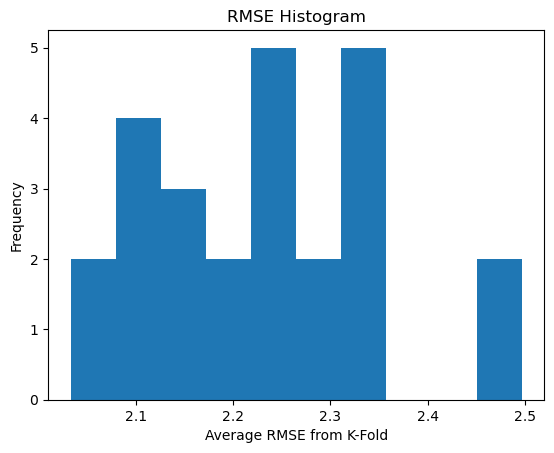

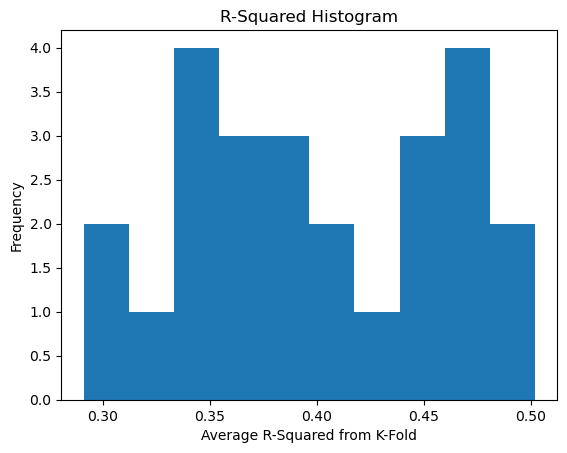

In [66]:
#running k-fold on different model varieties
#model 1
rmse_1, r2_1 = run_kfold(xtrain, ytrain, 
                                   hidden_size = 32, 
                                   num_layers = 1,
                                   lr = 0.01,
                                   loss_type = "mse",
                                   k = 5)

#model 2
rmse_2, r2_2 = run_kfold(xtrain, ytrain, hidden_size = 16, num_layers = 1, lr = 0.01, loss_type = 'mse', k = 5)
#model 3
rmse_3, r2_3 = run_kfold(xtrain, ytrain, 8, 1, 0.01, 'mse', k = 5)
#model 4
rmse_4, r2_4 = run_kfold(xtrain, ytrain, 8, 1, 0.01, 'mae', k = 5)
#model 5
rmse_5, r2_5 = run_kfold(xtrain, ytrain, 16, 1, 0.01, 'huber', k = 5)

#plotting a histogram of rmse and r2 values
all_rmses = rmse_1 + rmse_2 + rmse_3 + rmse_4 + rmse_5
all_r2s = r2_1 + r2_2 + r2_3 + r2_4 + r2_5
#RMSE
plt.hist(all_rmses)
plt.title("RMSE Histogram")
plt.xlabel("Average RMSE from K-Fold")
plt.ylabel("Frequency")
plt.show()

#R2s
plt.hist(all_r2s)
plt.title("R-Squared Histogram")
plt.xlabel("Average R-Squared from K-Fold")
plt.ylabel("Frequency")
plt.show()

In [67]:
#implementing no-kold method (for test set)
#train final model pipeline 
def run_model_no_kfold(
    X_train, y_train,
    X_val, y_val,
    input_size,
    hidden_size=64,
    num_layers=1,
    learning_rate=0.001,
    loss_type="mse",
    batch_size=32,
    num_epochs=30):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # build datasets
    train_ds = TensorDataset(
        torch.tensor(X_train, dtype=torch.float32),
        torch.tensor(y_train, dtype=torch.float32)
    )

    val_ds = TensorDataset(
        torch.tensor(X_val, dtype=torch.float32),
        torch.tensor(y_val, dtype=torch.float32)
    )

    # loaders
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    # model
    model = LSTMmodel(
        input_size=input_size,
        hidden_size=hidden_size,
        num_layers=num_layers
    ).to(device)

    # loss
    if loss_type == "mse":
        criterion = nn.MSELoss()
    elif loss_type == "mae":
        criterion = nn.L1Loss()
    elif loss_type == "huber":
        criterion = nn.SmoothL1Loss()

    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    # training loop
    for epoch in range(num_epochs):

        model.train()
        train_loss = 0

        for xbatch, ybatch in train_loader:
            xbatch = xbatch.to(device)
            ybatch = ybatch.to(device).view(-1,1)

            optimizer.zero_grad()
            preds = model(xbatch)  # make sure model returns [batch,1]
            loss = criterion(preds, ybatch)

            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        train_loss /= len(train_loader)

        # validation
        model.eval()
        val_loss = 0
        y_all, pred_all = [], []

        with torch.no_grad():
            for xbatch, ybatch in val_loader:
                xbatch = xbatch.to(device)
                ybatch = ybatch.to(device).view(-1,1)

                preds = model(xbatch)
                loss = criterion(preds, ybatch)

                val_loss += loss.item()

                y_all.append(ybatch.cpu())
                pred_all.append(preds.cpu())

        val_loss /= len(val_loader)

    # metrics
    y_all = torch.cat(y_all)
    pred_all = torch.cat(pred_all)

    y_np = y_all.numpy().ravel()
    pred_np = pred_all.numpy().ravel()

    rmse = np.sqrt(np.mean((pred_np - y_np) ** 2))
    r2 = r2_score(y_np, pred_np)

    return pred_all, y_all, model, rmse, r2


Test RMSE: 2.0876908
Test R2: 0.4920867085456848


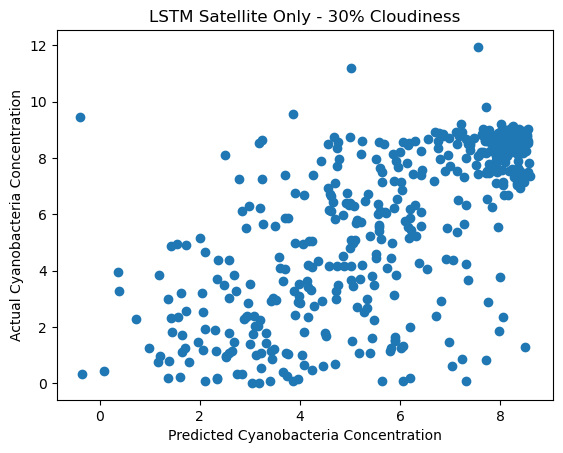

In [68]:
#get results on the test set
xtest, _ = scale_data(xtest, scaler=scaler, fit=False)
#plot predicted versus actual
preds, y_true, model, rmse, r2 = run_model_no_kfold(
    xtrain, ytrain,
    xtest, ytest,
    input_size=xtrain.shape[2],
    hidden_size=16,
    num_layers=1,
    learning_rate=0.01,
    loss_type="mse"
)

print("Test RMSE:", rmse)
preds = preds.numpy()
y_true = y_true.numpy()
r2 = r2_score(y_true, preds)
print("Test R2:", r2)

plt.scatter(preds, y_true)
plt.xlabel("Predicted Cyanobacteria Concentration")
plt.ylabel("Actual Cyanobacteria Concentration")
plt.title("LSTM Satellite Only - 30% Cloudiness")
plt.show()

#### 50% Cloudiness LSTM

In [69]:
df2 = pd.read_csv('cloud_50_8.csv')
print(df2.shape)

(43184, 20)


In [70]:
#sort
df2 = df2.sort_values(by = ['latitude', 'longitude', 'sample_date', 'cyanobacteria_abundance', 'satellite_date'])

In [71]:
#placing data into the correct format to load into the LSTM
feature_cols = ['NIR', 'SWIR', 'blue', 'green', 'ndci', 'ndti', 'ndvi', 'ndwi', 'red', 'red_edge', 'cloud_score', 'mean_diff_days', 'std_diff_days']
xdata2 = []
ydata2 = []

groups = ['latitude', 'longitude', 'sample_date', 'cyanobacteria_abundance'] 

for _, group in df2.groupby(groups):
    group = group.sort_values('satellite_date')

    #ensure sequence is of length 8
    if len(group) == 8:
        seq = group[feature_cols].values

        #input features
        xdata2.append(seq)

        #target feature
        ydata2.append(group['cyanobacteria_abundance'].iloc[0])

xdata2 = np.array(xdata2)
ydata2 = np.array(ydata2)

#take log of cyanobacteria abundance
ydata2 = np.log1p(ydata2)

print(xdata2.shape)
print(ydata2.shape)

(5398, 8, 13)
(5398,)


In [72]:
#scale and split into test / train groups 
xtrain2, xtest2, ytrain2, ytest2 = train_test_split(x_scaled2, ydata2, test_size = 0.1, random_state = 999)
xtrain2, scaler = scale_data(xtrain2, fit=True)

hidden size = 32, lr = 0.01, loss type = mse
RMSE: 2.158 ± 0.046
R2: 0.459 ± 0.017

hidden size = 16, lr = 0.01, loss type = mse
RMSE: 2.157 ± 0.046
R2: 0.460 ± 0.014

hidden size = 8, lr = 0.01, loss type = mse
RMSE: 2.156 ± 0.023
R2: 0.460 ± 0.010

hidden size = 8, lr = 0.01, loss type = mae
RMSE: 2.243 ± 0.107
R2: 0.415 ± 0.055

hidden size = 16, lr = 0.01, loss type = huber
RMSE: 2.198 ± 0.047
R2: 0.439 ± 0.023



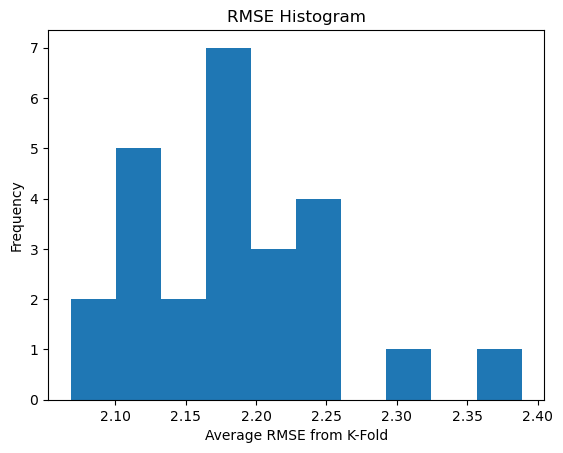

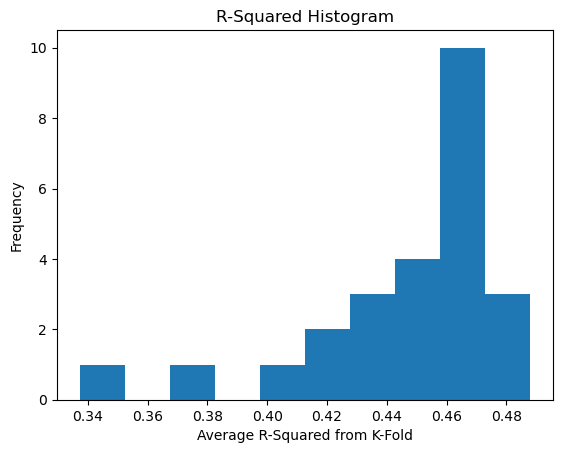

In [73]:
#running k-fold on different model varieties - 50%
#model 1
rmse_1, r2_1 = run_kfold(xtrain2, ytrain2, 
                                   hidden_size = 32, 
                                   num_layers = 1,
                                   lr = 0.01,
                                   loss_type = "mse",
                                   k = 5)

#model 2
rmse_2, r2_2 = run_kfold(xtrain2, ytrain2, hidden_size = 16, num_layers = 1, lr = 0.01, loss_type = 'mse', k = 5)
#model 3
rmse_3, r2_3 = run_kfold(xtrain2, ytrain2, 8, 1, 0.01, 'mse', k = 5)
#model 4
rmse_4, r2_4 = run_kfold(xtrain2, ytrain2, 8, 1, 0.01, 'mae', k = 5)
#model 5
rmse_5, r2_5 = run_kfold(xtrain2, ytrain2, 16, 1, 0.01, 'huber', k = 5)

#plotting a histogram of rmse and r2 values
all_rmses = rmse_1 + rmse_2 + rmse_3 + rmse_4 + rmse_5
all_r2s = r2_1 + r2_2 + r2_3 + r2_4 + r2_5
#RMSE
plt.hist(all_rmses)
plt.title("RMSE Histogram")
plt.xlabel("Average RMSE from K-Fold")
plt.ylabel("Frequency")
plt.show()

#R2s
plt.hist(all_r2s)
plt.title("R-Squared Histogram")
plt.xlabel("Average R-Squared from K-Fold")
plt.ylabel("Frequency")
plt.show()

Test RMSE: 1.8966151
Test R2: 0.5529292225837708


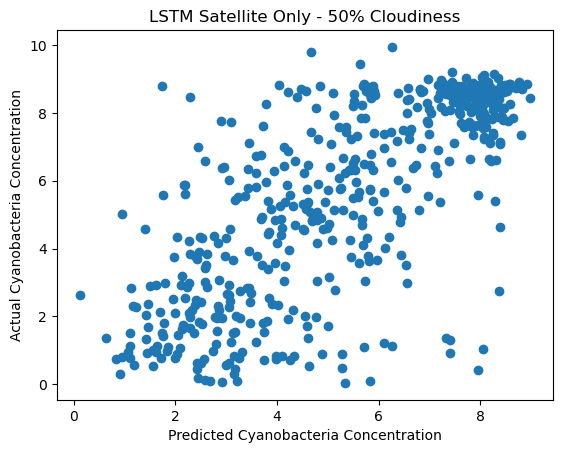

In [75]:
#get results on the test set -- 50%
xtest2, _ = scale_data(xtest2, scaler=scaler, fit=False)
#plot predicted versus actual
preds, y_true, model, rmse, r2 = run_model_no_kfold(
    xtrain2, ytrain2,
    xtest2, ytest2,
    input_size=xtrain2.shape[2],
    hidden_size=16,
    num_layers=1,
    learning_rate=0.01,
    loss_type="mse"
)

print("Test RMSE:", rmse)
preds = preds.numpy()
y_true = y_true.numpy()
r2 = r2_score(y_true, preds)
print("Test R2:", r2)

plt.scatter(preds, y_true)
plt.xlabel("Predicted Cyanobacteria Concentration")
plt.ylabel("Actual Cyanobacteria Concentration")
plt.title("LSTM Satellite Only - 50% Cloudiness")
plt.show()

#### 70% Cloudiness Model

In [85]:
df3 = pd.read_csv('cloud_70_9.csv')
print(df3.shape)

(50580, 20)


In [86]:
#sort
df3 = df3.sort_values(by = ['latitude', 'longitude', 'sample_date', 'cyanobacteria_abundance', 'satellite_date'])

In [87]:
#placing data into the correct format to load into the LSTM
feature_cols = ['NIR', 'SWIR', 'blue', 'green', 'ndci', 'ndti', 'ndvi', 'ndwi', 'red', 'red_edge', 'cloud_score', 'mean_diff_days', 'std_diff_days']
xdata3 = []
ydata3 = []

groups = ['latitude', 'longitude', 'sample_date', 'cyanobacteria_abundance'] 

for _, group in df3.groupby(groups):
    group = group.sort_values('satellite_date')

    #ensure sequence is of length 9
    if len(group) == 9:
        seq = group[feature_cols].values

        #input features
        xdata3.append(seq)

        #target feature
        ydata3.append(group['cyanobacteria_abundance'].iloc[0])

xdata3 = np.array(xdata3)
ydata3 = np.array(ydata3)

#take log of cyanobacteria abundance
ydata3 = np.log1p(ydata3)

print(xdata3.shape)
print(ydata3.shape)

(5620, 9, 13)
(5620,)


In [88]:
#scale and split into test / train groups 
xtrain3, xtest3, ytrain3, ytest3 = train_test_split(x_scaled3, ydata3, test_size = 0.1, random_state = 999)
xtrain3, scaler = scale_data(xtrain3, fit=True)

hidden size = 32, lr = 0.01, loss type = mse
RMSE: 2.156 ± 0.078
R2: 0.459 ± 0.043

hidden size = 16, lr = 0.01, loss type = mse
RMSE: 2.120 ± 0.056
R2: 0.478 ± 0.028

hidden size = 8, lr = 0.01, loss type = mse
RMSE: 2.143 ± 0.052
R2: 0.466 ± 0.029

hidden size = 8, lr = 0.01, loss type = mae
RMSE: 2.279 ± 0.107
R2: 0.395 ± 0.061

hidden size = 16, lr = 0.01, loss type = huber
RMSE: 2.211 ± 0.073
R2: 0.431 ± 0.041



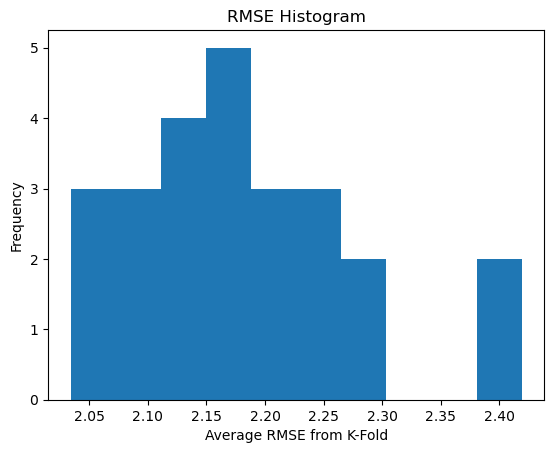

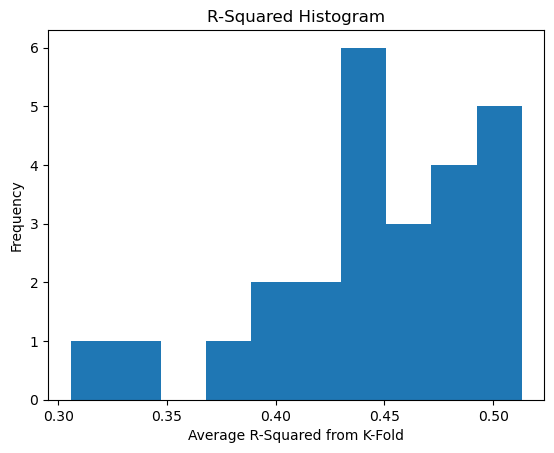

In [89]:
#running k-fold on different model varieties - 70%
#model 1
rmse_1, r2_1 = run_kfold(xtrain3, ytrain3, 
                                   hidden_size = 32, 
                                   num_layers = 1,
                                   lr = 0.01,
                                   loss_type = "mse",
                                   k = 5)

#model 2
rmse_2, r2_2 = run_kfold(xtrain3, ytrain3, hidden_size = 16, num_layers = 1, lr = 0.01, loss_type = 'mse', k = 5)
#model 3
rmse_3, r2_3 = run_kfold(xtrain3, ytrain3, 8, 1, 0.01, 'mse', k = 5)
#model 4
rmse_4, r2_4 = run_kfold(xtrain3, ytrain3, 8, 1, 0.01, 'mae', k = 5)
#model 5
rmse_5, r2_5 = run_kfold(xtrain3, ytrain3, 16, 1, 0.01, 'huber', k = 5)

#plotting a histogram of rmse and r2 values
all_rmses = rmse_1 + rmse_2 + rmse_3 + rmse_4 + rmse_5
all_r2s = r2_1 + r2_2 + r2_3 + r2_4 + r2_5
#RMSE
plt.hist(all_rmses)
plt.title("RMSE Histogram")
plt.xlabel("Average RMSE from K-Fold")
plt.ylabel("Frequency")
plt.show()

#R2s
plt.hist(all_r2s)
plt.title("R-Squared Histogram")
plt.xlabel("Average R-Squared from K-Fold")
plt.ylabel("Frequency")
plt.show()

Test RMSE: 1.9847394
Test R2: 0.5618115663528442


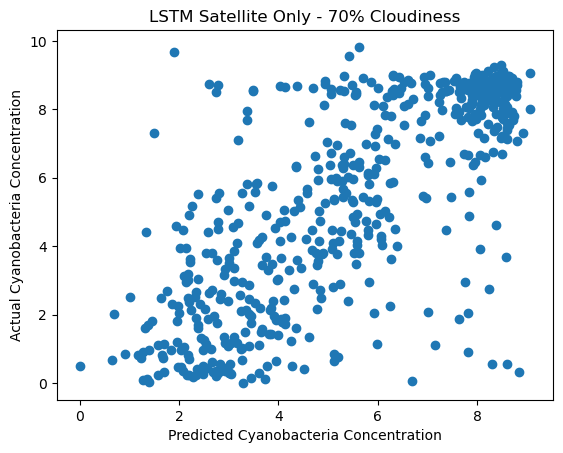

In [90]:
#get results on the test set -- 70%
xtest3, _ = scale_data(xtest3, scaler=scaler, fit=False)
#plot predicted versus actual
preds, y_true, model, rmse, r2 = run_model_no_kfold(
    xtrain3, ytrain3,
    xtest3, ytest3,
    input_size=xtrain3.shape[2],
    hidden_size=16,
    num_layers=1,
    learning_rate=0.01,
    loss_type="mse"
)

print("Test RMSE:", rmse)
preds = preds.numpy()
y_true = y_true.numpy()
r2 = r2_score(y_true, preds)
print("Test R2:", r2)

plt.scatter(preds, y_true)
plt.xlabel("Predicted Cyanobacteria Concentration")
plt.ylabel("Actual Cyanobacteria Concentration")
plt.title("LSTM Satellite Only - 70% Cloudiness")
plt.show()